## Library Imports

In [1]:
# install csep python library
#!pip install cartopy
#!pip install pyCSEP
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import cartopy
import csep
from csep.utils import datasets, time_utils, plots
from csep.core import poisson_evaluations as poisson
from scipy.stats import poisson as poisson_stat

import sys
import os
sys.path.append(os.path.abspath("../src"))
# import functions for hdf5 forecast format
import functions_for_hdf5_parallel as f_hdf5
# import functions to calculate the Q and L-Scores
import QandL as QL

Catalog of observed events used in Section 4 can be obtained for any time frame depending on the year/month/day hour\:minute\:second. On the paper we only focused on a time frame of a calendar year. Model forecasts can be obtained depending on the day/month/year. This can only be done depending on the date that the model was run. For start and end dates, please refer to: https://cseptesting.org/grid-based-forecasts/ Model's forecast can also be dowloaded from there.

NOTE: Forecast data has to be downloaded before running the following code. Files are in hdf5 format.

## 2008

Fetched ComCat catalog in 2.5324418544769287 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2008-01-02 03:48:12.500000+00:00
End Date: 2008-12-31 22:56:00.220000+00:00
Min Latitude: 31.5038333 and Max Latitude: 42.0371667
Min Longitude: -125.3458333 and Max Longitude: -113.1393333
Min Magnitude: 2.5
Found 1703 events in the ComCat catalog.

        Name: None

        Start Date: 2008-01-19 17:18:46.470000+00:00
        End Date: 2008-12-28 05:17:07.470000+00:00

        Latitude: (31.8333333, 41.1885)
        Longitude: (-125.3406667, -115.2295)

        Min Mw: 3.95
        Max Mw: 5.44

        Event Count: 55
        


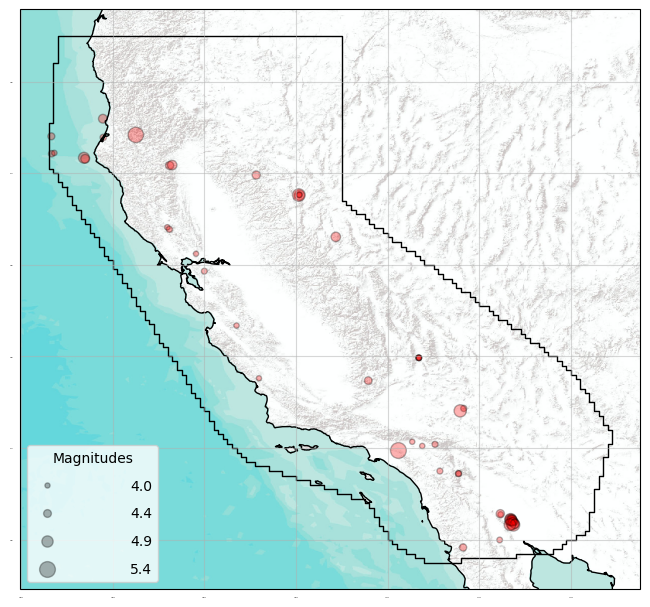

<GeoAxes: >

In [2]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2008-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2008-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)

# Plot of the location of observed events proportional to their magnitude
catalog.plot(show=True)

### ETAS

In [3]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2008', # format dd/mm/yyyy
                                     end_date = '31/12/2008')

Loading year: 2008
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [4]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

0.06188879270172224


In [4]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
#Here we are retaining the top 5% of observed magnitudes
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.47329792


#### L-Score

In [5]:
print(QL.ell_score(fore_df= ETAS_forec,
                        cat_df = catalogEvents))

# Optional to free memory space
del ETAS_forec

-330.7752


### STEP

In [5]:
## Load STEP model
## start date: 01 Aug. 2007    end date: 21 Jan. 2013
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder****
# file name is assumed to not have been renamed from download
step_filename = '../data/STEP_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEP = f_hdf5.load_hdf5_to_dict(step_filename,
                                     start_date = '01/01/2008', # format dd/mm/yyyy
                                     end_date = '31/12/2008')

Loading year: 2008
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [6]:
STEPforecast = QL.combine_forecast_dataframes(STEP)
del STEP

QSTEP = QL.q_score_calc(
    forecast_df=STEPforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEP)

del STEPforecast

0.019389059072789296


In [7]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEP.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEP_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del STEP
del all_df

#Q Score Calculation with different percentage retention
#Here we are retaining the top 5% of observed magnitudes
print(QL.calculate_Q_score(fore_df= STEP_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.4931226


#### L-Score

In [8]:
print(QL.ell_score(fore_df= STEP_forec,
                    cat_df = catalogEvents))

#Optional to free memory space
del STEP_forec

-211.03438


## 2009

Fetched ComCat catalog in 2.868523359298706 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2009-01-01 03:37:59.850000+00:00
End Date: 2009-12-31 19:57:42.940000+00:00
Min Latitude: 31.5523333 and Max Latitude: 42.5413333
Min Longitude: -125.398 and Max Longitude: -113.1813333
Min Magnitude: 2.5
Found 1207 events in the ComCat catalog.

        Name: None

        Start Date: 2009-01-04 17:27:10.480000+00:00
        End Date: 2009-12-30 19:07:41.530000+00:00

        Latitude: (31.711, 42.5413333)
        Longitude: (-124.637, -114.539)

        Min Mw: 3.95
        Max Mw: 5.8

        Event Count: 43
        


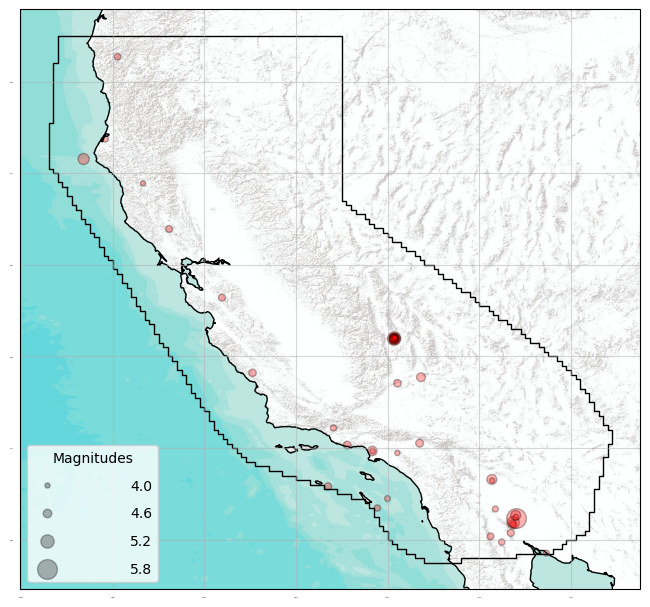

<GeoAxes: >

In [7]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2009-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2009-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)

# Plot of the location of observed events proportional to their magnitude
catalog.plot(show=True)

### ETAS

In [8]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2009', # format dd/mm/yyyy
                                     end_date = '31/12/2009')

Loading year: 2009
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [9]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

0.7176976565583089


In [11]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.6609501


#### L-Score

In [12]:
print(QL.ell_score(fore_df= ETAS_forec,
                        cat_df = catalogEvents))
#Optional to free memory space
del ETAS_forec

-276.55215


### STEP

In [10]:
## Load STEP model
## start date: 01 Aug. 2007    end date: 21 Jan. 2013
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
step_filename = '../data/STEP_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEP = f_hdf5.load_hdf5_to_dict(step_filename,
                                     start_date = '01/01/2009', # format dd/mm/yyyy
                                     end_date = '31/12/2009')

Loading year: 2009
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [11]:
STEPforecast = QL.combine_forecast_dataframes(STEP)
del STEP

QSTEP = QL.q_score_calc(
    forecast_df=STEPforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEP)

del STEPforecast

1.4089526693407273


In [14]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEP.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEP_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del STEP
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEP_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.9303938


#### L-Score

In [15]:
print(QL.ell_score(fore_df= STEP_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del STEP_forec

-165.31847


### KJSSOneDay

In [12]:
## Load KJSSOneDay model
## start date: 01 Jan. 2009    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
KJSSOne_filename = '../data/KJSSOneDayCalifornia_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
KJSSOne = f_hdf5.load_hdf5_to_dict(KJSSOne_filename,
                                     start_date = '01/01/2009', # format dd/mm/yyy
                                     end_date = '31/12/2009')

Loading year: 2009
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [13]:
KJSSOneforecast = QL.combine_forecast_dataframes(KJSSOne)
del KJSSOne

QKJSSOne = QL.q_score_calc(
    forecast_df=KJSSOneforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QKJSSOne)

del KJSSOneforecast

0.7467965913313468


In [17]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in KJSSOne.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
KJSSOne_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del KJSSOne
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= KJSSOne_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.584117


#### L-Score

In [19]:
#L-score diverges
print(QL.ell_score(fore_df= KJSSOne_forec,
                    cat_df = catalogEvents))

# add waterlevelto zero valued bins
print(QL.ell_score(fore_df= KJSSOne_forec,
                    cat_df = catalogEvents, 
                    waterlevel = 1e-6))

#Optional to free memory space
del KJSSOne_forec

C:\Users\arjon\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


-inf
-224.68491759829112


C:\Users\arjon\OneDrive\Documents\S Score\Project\src\QandL.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df_out.iloc[target_idx,6] = waterlevel


## 2010

Fetched ComCat catalog in 4.15903639793396 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2010-01-01 02:33:42.820000+00:00
End Date: 2010-12-31 17:59:32.590000+00:00
Min Latitude: 31.5136667 and Max Latitude: 42.4743333
Min Longitude: -125.399 and Max Longitude: -113.1186667
Min Magnitude: 2.5
Found 4998 events in the ComCat catalog.

        Name: None

        Start Date: 2010-01-04 14:24:54.440000+00:00
        End Date: 2010-12-23 12:37:35.020000+00:00

        Latitude: (31.715, 40.9511667)
        Longitude: (-125.2775, -114.8613333)

        Min Mw: 3.95
        Max Mw: 7.2

        Event Count: 187
        


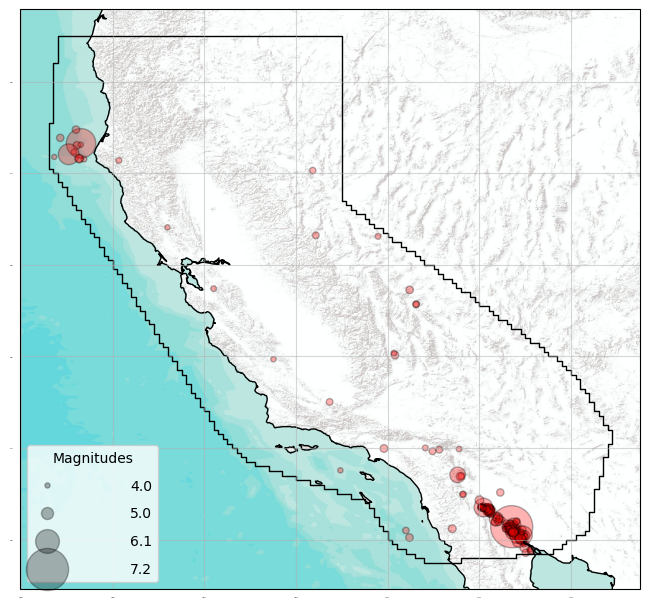

<GeoAxes: >

In [14]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2010-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2010-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)
catalog.plot(show=True)

### ETAS

In [15]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2010', # format dd/mm/yyyy
                                     end_date = '31/12/2010')

Loading year: 2010
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [16]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

0.11502667457211549


In [22]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.0597266


#### L-Score

In [23]:
print(QL.ell_score(fore_df= ETAS_forec,
                        cat_df = catalogEvents))

#Optional to free memory space
del ETAS_forec

-667.6469


### STEP 

In [17]:
## Load STEP model
## start date: 01 Aug. 2007    end date: 21 Jan. 2013
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
step_filename = '../data/STEP_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEP = f_hdf5.load_hdf5_to_dict(step_filename,
                                     start_date = '01/01/2010', # format dd/mm/yyyy
                                     end_date = '31/12/2010')

Loading year: 2010
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [18]:
STEPforecast = QL.combine_forecast_dataframes(STEP)
del STEP

QSTEP = QL.q_score_calc(
    forecast_df=STEPforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEP)

del STEPforecast

0.12368276722124215


In [25]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEP.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEP_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del STEP
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEP_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

4.006758


#### L-Score

In [26]:
print(QL.ell_score(fore_df= STEP_forec,
                        cat_df = catalogEvents))
#Optional to free memory space
del STEP_forec

-468.13376


### KJSSOneDay

In [19]:
## Load KJSSOneDay model
## start date: 01 Jan. 2009    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
KJSSOne_filename = '../data/KJSSOneDayCalifornia_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
KJSSOne = f_hdf5.load_hdf5_to_dict(KJSSOne_filename,
                                     start_date = '01/01/2010', # format dd/mm/yyy
                                     end_date = '31/12/2010')

Loading year: 2010
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [20]:
KJSSOneforecast = QL.combine_forecast_dataframes(KJSSOne)
del KJSSOne

QKJSSOne = QL.q_score_calc(
    forecast_df=KJSSOneforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QKJSSOne)

del KJSSOneforecast

0.12424213670507889


In [28]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in KJSSOne.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
KJSSOne_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del KJSSOne
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= KJSSOne_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.1648054


#### L-Score

In [29]:
print(QL.ell_score(fore_df= KJSSOne_forec,
                    cat_df = catalogEvents))

#Optional to free memory space
del KJSSOne_forec

-634.06274


## 2011

Fetched ComCat catalog in 1.2087690830230713 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2011-01-01 00:34:10.130000+00:00
End Date: 2011-12-31 19:14:44.380000+00:00
Min Latitude: 31.5168333 and Max Latitude: 42.6163333
Min Longitude: -125.3978333 and Max Longitude: -113.1328333
Min Magnitude: 2.5
Found 1386 events in the ComCat catalog.

        Name: None

        Start Date: 2011-01-08 00:10:16.740000+00:00
        End Date: 2011-12-30 15:34:29.360000+00:00

        Latitude: (31.8105, 41.027)
        Longitude: (-125.363, -114.6905)

        Min Mw: 3.95
        Max Mw: 5.09

        Event Count: 48
        


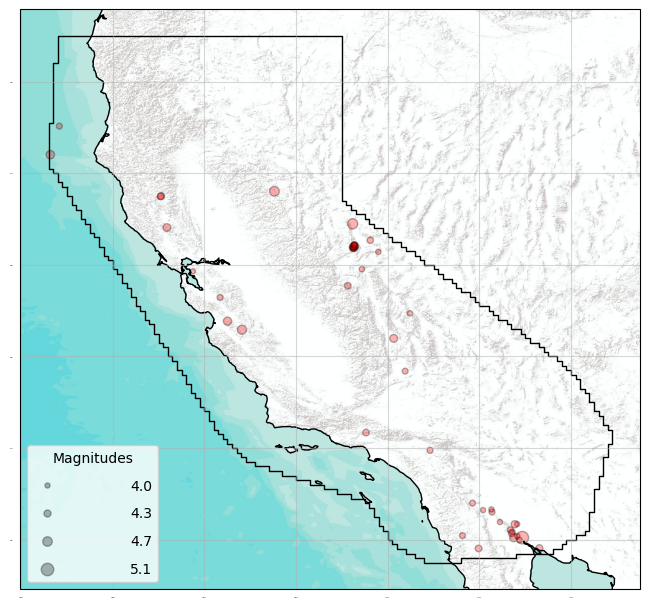

<GeoAxes: >

In [21]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2011-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2011-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)
catalog.plot(show=True)

### ETAS

In [22]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2011', # format dd/mm/yyyy
                                     end_date = '31/12/2011')

Loading year: 2011
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [23]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

0.647181546673954


In [32]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.9381611


#### L-Score

In [33]:
print(QL.ell_score(fore_df= ETAS_forec,
                    cat_df = catalogEvents))

#Optional to free memory space
del ETAS_forec

-295.47137


### STEP

In [24]:
## Load STEP model
## start date: 01 Aug. 2007    end date: 21 Jan. 2013
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
step_filename = '../data/STEP_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEP = f_hdf5.load_hdf5_to_dict(step_filename,
                                     start_date = '01/01/2011', # format dd/mm/yyyy
                                     end_date = '31/12/2011')

Loading year: 2011
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [25]:
STEPforecast = QL.combine_forecast_dataframes(STEP)
del STEP

QSTEP = QL.q_score_calc(
    forecast_df=STEPforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEP)

del STEPforecast

0.16445209985888368


In [35]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEP.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEP_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del STEP
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEP_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.7694991


#### L-Score

In [36]:
print(QL.ell_score(fore_df= STEP_forec,
                        cat_df = catalogEvents))
#Optional to free memory space
del STEP_forec

-210.34457


### STEPJAVA

In [26]:
## Load STEPJAVA model
## start date: 01 Sep. 2010    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
STEPJAVA_filename = '../data/STEPJAVA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEPJAVA = f_hdf5.load_hdf5_to_dict(STEPJAVA_filename,
                                     start_date = '01/01/2011', # format dd/mm/yyy
                                     end_date = '31/12/2011')

Loading year: 2011
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [27]:
STEPJAVAforecast = QL.combine_forecast_dataframes(STEPJAVA)
del STEPJAVA

QSTEPJAVA = QL.q_score_calc(
    forecast_df=STEPJAVAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEPJAVA)

del STEPJAVAforecast

0.1405809874639306


In [42]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEPJAVA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEPJAVA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del STEPJAVA
del all_df
#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEPJAVA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.9638286


#### L-Score

In [43]:
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents))

# add waterlevelto zero valued bins
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents,
                 waterlevel = 1e-6))

#Optional to free memory space
del STEPJAVA_forec

C:\Users\arjon\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


-inf


C:\Users\arjon\OneDrive\Documents\S Score\Project\src\QandL.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df_out.iloc[target_idx,6] = waterlevel


-254.19117290238606


### KJSSOneDay

In [28]:
## Load KJSSOneDay model
## start date: 01 Jan. 2009    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
KJSSOne_filename = '../data/KJSSOneDayCalifornia_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
KJSSOne = f_hdf5.load_hdf5_to_dict(KJSSOne_filename,
                                     start_date = '01/01/2011', # format dd/mm/yyy
                                     end_date = '31/12/2011')

Loading year: 2011
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [29]:
KJSSOneforecast = QL.combine_forecast_dataframes(KJSSOne)
del KJSSOne

QKJSSOne = QL.q_score_calc(
    forecast_df=KJSSOneforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QKJSSOne)

del KJSSOneforecast

0.13019870393861346


In [45]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in KJSSOne.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
KJSSOne_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del KJSSOne
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= KJSSOne_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.82929504


#### L-Score

In [46]:
print(QL.ell_score(fore_df= KJSSOne_forec,
                    cat_df = catalogEvents))

#Optional to free memory space
del KJSSOne_forec

-248.3789


## 2012

Fetched ComCat catalog in 2.8086905479431152 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2012-01-02 07:02:46.080000+00:00
End Date: 2012-12-30 12:25:45.570000+00:00
Min Latitude: 31.5135 and Max Latitude: 42.8158333
Min Longitude: -125.3935 and Max Longitude: -113.126
Min Magnitude: 2.5
Found 1193 events in the ComCat catalog.

        Name: None

        Start Date: 2012-01-17 09:55:00.520000+00:00
        End Date: 2012-12-22 21:37:45.140000+00:00

        Latitude: (31.8735, 41.1431667)
        Longitude: (-125.3308333, -114.9953333)

        Min Mw: 3.95
        Max Mw: 5.6

        Event Count: 50
        


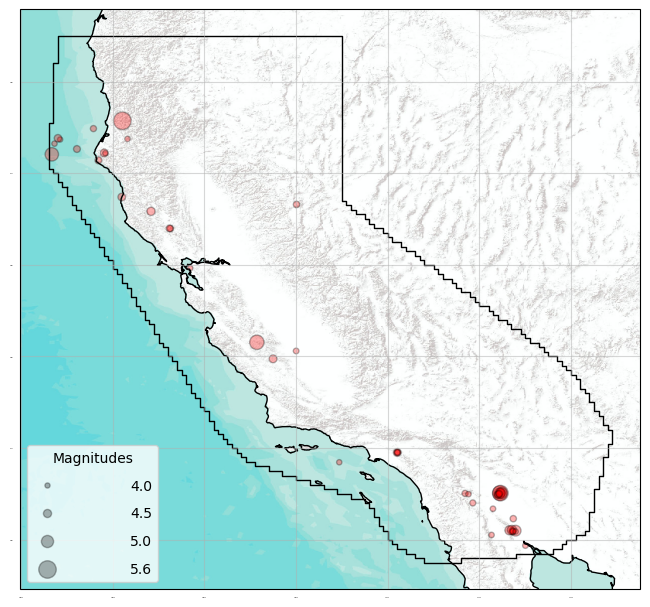

<GeoAxes: >

In [30]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2012-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2012-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)
catalog.plot(show=True)

### ETAS

In [31]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2012', # format dd/mm/yyyy
                                     end_date = '31/12/2012')

Loading year: 2012
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [32]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

0.047027580749741636


In [44]:
#Initialize an empty list to store data

all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.3083407


#### L-Score

In [50]:
print(QL.ell_score(fore_df= ETAS_forec,
                    cat_df = catalogEvents,))

#Optional to free memory space
del ETAS_forec

-295.56293


### STEP

In [33]:
## Load STEP model
## start date: 01 Aug. 2007    end date: 21 Jan. 2013
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
step_filename = '../data/STEP_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEP = f_hdf5.load_hdf5_to_dict(step_filename,
                                     start_date = '01/01/2012', # format dd/mm/yyyy
                                     end_date = '31/12/2012')

Loading year: 2012
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [34]:
STEPforecast = QL.combine_forecast_dataframes(STEP)
del STEP

QSTEP = QL.q_score_calc(
    forecast_df=STEPforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEP)

del STEPforecast

0.003625427144993277


In [52]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEP.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEP_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del STEP
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEP_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.1330402


#### L-Score

In [53]:
print(QL.ell_score(fore_df= STEP_forec,
                        cat_df = catalogEvents))
#Optional to free memory space
del STEP_forec

-178.90196


### STEPJAVA

In [35]:
## Load STEPJAVA model
## start date: 01 Sep. 2010    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
STEPJAVA_filename = '../data/STEPJAVA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEPJAVA = f_hdf5.load_hdf5_to_dict(STEPJAVA_filename,
                                     start_date = '01/01/2012', # format dd/mm/yyy
                                     end_date = '31/12/2012')

Loading year: 2012
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [36]:
STEPJAVAforecast = QL.combine_forecast_dataframes(STEPJAVA)
del STEPJAVA

QSTEPJAVA = QL.q_score_calc(
    forecast_df=STEPJAVAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEPJAVA)

del STEPJAVAforecast

0.002473973955324287


In [55]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEPJAVA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEPJAVA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del STEPJAVA
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEPJAVA_forec,
                            cat_df = catalogEvents,
                            perc_retain = 0.05))

3.4390044


#### L-Score

In [56]:
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents))

# add waterlevelto zero valued bins
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents,
                 waterlevel = 1e-6))

#Optional to free memory space
del STEPJAVA_forec

C:\Users\arjon\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


-inf
-259.42454567440916


C:\Users\arjon\OneDrive\Documents\S Score\Project\src\QandL.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df_out.iloc[target_idx,6] = waterlevel


### KJSSOneDay

In [37]:
## Load KJSSOneDay model
## start date: 01 Jan. 2009    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
KJSSOne_filename = '../data/KJSSOneDayCalifornia_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
KJSSOne = f_hdf5.load_hdf5_to_dict(KJSSOne_filename,
                                     start_date = '01/01/2012', # format dd/mm/yyy
                                     end_date = '31/12/2012')

Loading year: 2012
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [38]:
KJSSOneforecast = QL.combine_forecast_dataframes(KJSSOne)
del KJSSOne

QKJSSOne = QL.q_score_calc(
    forecast_df=KJSSOneforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QKJSSOne)

del KJSSOneforecast

0.0003407034348056477


In [58]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in KJSSOne.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
KJSSOne_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del KJSSOne
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= KJSSOne_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.1022449


#### L-Score

In [59]:
print(QL.ell_score(fore_df= KJSSOne_forec,
                    cat_df = catalogEvents))

#Optional to free memory space
del KJSSOne_forec

-274.85934


## 2013

Fetched ComCat catalog in 3.004007339477539 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2013-01-01 23:37:09.760000+00:00
End Date: 2013-12-31 12:33:24.330000+00:00
Min Latitude: 31.5003333 and Max Latitude: 42.967
Min Longitude: -125.3931667 and Max Longitude: -113.1058333
Min Magnitude: 2.5
Found 1174 events in the ComCat catalog.

        Name: None

        Start Date: 2013-01-13 10:28:17.650000+00:00
        End Date: 2013-12-26 00:18:19.630000+00:00

        Latitude: (32.132, 41.3256667)
        Longitude: (-125.316, -115.2148333)

        Min Mw: 3.95
        Max Mw: 5.69

        Event Count: 35
        


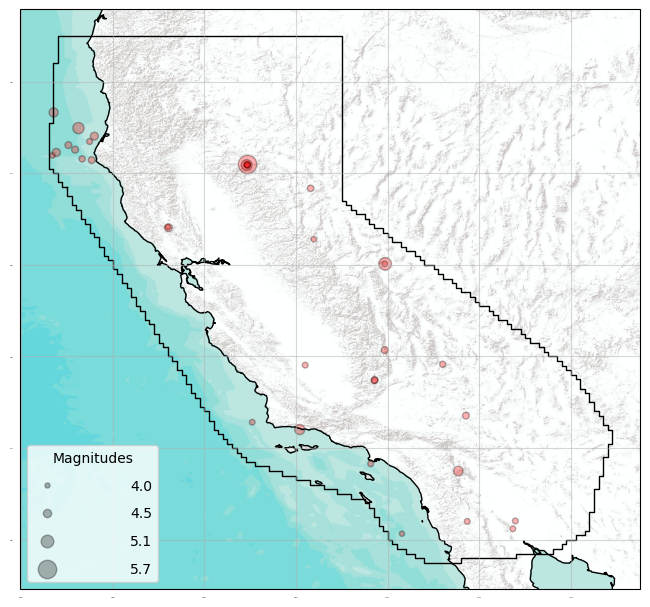

<GeoAxes: >

In [39]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2013-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2013-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)
catalog.plot(show=True)

### ETAS

In [40]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [41]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

0.37689289226024764


In [62]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.0945928


#### L-Score

In [63]:
print(QL.ell_score(fore_df= ETAS_forec,
                    cat_df = catalogEvents))

#Optional to free memory space
del ETAS_forec

-242.07106


### ETASV1.1

In [42]:
## Load ETASV1.1 model
## start date: 01 July 2012    end date: 30 June 2018
## missing days: 4      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETASV1_1_filename = '../data/ETASV1_1_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETASV1_1 = f_hdf5.load_hdf5_to_dict(ETASV1_1_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [43]:
ETASV1_1forecast = QL.combine_forecast_dataframes(ETASV1_1)
del ETASV1_1

QETASV1_1 = QL.q_score_calc(
    forecast_df=ETASV1_1forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETASV1_1)

del ETASV1_1forecast

0.07851924535001405


In [92]:
all_df = []
#Loop through the nested dictionary
for year, months in ETASV1_1.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETASV1_1_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETASV1_1

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETASV1_1_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.8001409


#### L-Score

In [93]:
print(QL.ell_score(fore_df= ETASV1_1_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETASV1_1_forec

-170.21208


### ETAS_DROneDayMd2

In [44]:
## Load ETAS_DROneDayMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 17       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd2_filename = '../data/ETAS_DROneDayMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd2_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [51]:
ETAS_DROneDayMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd2)
del ETAS_DROneDayMd2

QETAS_DROneDayMd2 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd2)

del ETAS_DROneDayMd2forecast

0.015187122202756507


In [77]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS_DROneDayMd2
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.3288572


#### L-Score

In [78]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd2_forec

-165.19568


### ETAS_DROneDayMd3

In [52]:
## Load ETAS_DROneDayMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd3_filename = '../data/ETAS_DROneDayMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd3_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [53]:
ETAS_DROneDayMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd3)
del ETAS_DROneDayMd3

QETAS_DROneDayMd3 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd3)

del ETAS_DROneDayMd3forecast

0.0049365135288161385


In [74]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS_DROneDayMd3
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.402239


#### L-Score

In [75]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd3_forec

-161.70676


### ETAS_HWMd2

In [54]:
## Load ETAS_HWMd2 model
## start date: 01 Oct. 2012    end date: 19 Sep. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HWMd2_filename = '../data/ETAS_HWMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HWMd2 = f_hdf5.load_hdf5_to_dict(ETAS_HWMd2_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [55]:
ETAS_HWMd2forecast = QL.combine_forecast_dataframes(ETAS_HWMd2)
del ETAS_HWMd2

QETAS_HWMd2 = QL.q_score_calc(
    forecast_df=ETAS_HWMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HWMd2)

del ETAS_HWMd2forecast

0.03328968046294846


In [104]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HWMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HWMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HWMd2

print(QL.calculate_Q_score(fore_df= ETAS_HWMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.725862


#### L-Score

In [105]:
print(QL.ell_score(fore_df= ETAS_HWMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HWMd2_forec

-164.77116


### ETAS_HWMd3

In [56]:
## Load ETAS_HWMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HWMd3_filename = '../data/ETAS_HWMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HWMd3 = f_hdf5.load_hdf5_to_dict(ETAS_HWMd3_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [57]:
ETAS_HWMd3forecast = QL.combine_forecast_dataframes(ETAS_HWMd3)
del ETAS_HWMd3

QETAS_HWMd3 = QL.q_score_calc(
    forecast_df=ETAS_HWMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HWMd3)

del ETAS_HWMd3forecast

0.030731575195700668


In [89]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HWMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HWMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS_HWMd3
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HWMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.9237862


#### L-Score

In [90]:
print(QL.ell_score(fore_df= ETAS_HWMd3_forec,
                     cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HWMd3_forec

-164.83995


### STEPJAVA

In [58]:
## Load STEPJAVA model
## start date: 01 Sep. 2010    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
STEPJAVA_filename = '../data/STEPJAVA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEPJAVA = f_hdf5.load_hdf5_to_dict(STEPJAVA_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [59]:
STEPJAVAforecast = QL.combine_forecast_dataframes(STEPJAVA)
del STEPJAVA

QSTEPJAVA = QL.q_score_calc(
    forecast_df=STEPJAVAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEPJAVA)

del STEPJAVAforecast

0.001473300955735438


In [68]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEPJAVA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEPJAVA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del STEPJAVA
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEPJAVA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.32946


#### L-Score

In [69]:
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents))

# add waterlevelto zero valued bins
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents,
                 waterlevel = 1e-6))

#Optional to free memory space
del STEPJAVA_forec

C:\Users\arjon\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


-inf
-229.90321807193112


C:\Users\arjon\OneDrive\Documents\S Score\Project\src\QandL.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df_out.iloc[target_idx,6] = waterlevel


### KJSSOneDay

In [60]:
## Load KJSSOneDay model
## start date: 01 Jan. 2009    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
KJSSOne_filename = '../data/KJSSOneDayCalifornia_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
KJSSOne = f_hdf5.load_hdf5_to_dict(KJSSOne_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [61]:
KJSSOneforecast = QL.combine_forecast_dataframes(KJSSOne)
del KJSSOne

QKJSSOne = QL.q_score_calc(
    forecast_df=KJSSOneforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QKJSSOne)

del KJSSOneforecast

0.0005315438392833377


In [65]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in KJSSOne.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
KJSSOne_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del KJSSOne
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= KJSSOne_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.8443582


#### L-Score

In [66]:
print(QL.ell_score(fore_df= KJSSOne_forec,
                    cat_df = catalogEvents))

#Optional to free memory space
del KJSSOne_forec

-197.21999


### K3Md2

In [62]:
## Load K3Md2 Model model
## start date: 01 Oct. 2012    end date: 19 Sep. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
K3Md2_filename = '../data/K3Md2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
K3Md2 = f_hdf5.load_hdf5_to_dict(K3Md2_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013') 

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [63]:
K3Md2forecast = QL.combine_forecast_dataframes(K3Md2)
del K3Md2

QK3Md2= QL.q_score_calc(
    forecast_df=K3Md2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QK3Md2)

del K3Md2forecast

0.061083088666203496


In [107]:
all_df = []
#Loop through the nested dictionary
for year, months in K3Md2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
K3Md2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del K3Md2

print(QL.calculate_Q_score(fore_df= K3Md2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.4439728


#### L-Score

In [108]:
print(QL.ell_score(fore_df= K3Md2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del K3Md2_forec

-195.63097


### K3Md3

In [64]:
## Load K3Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
K3Md3_filename = '../data/K3Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
K3Md3 = f_hdf5.load_hdf5_to_dict(K3Md3_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [65]:
K3Md3forecast = QL.combine_forecast_dataframes(K3Md3)
del K3Md3

QK3Md3= QL.q_score_calc(
    forecast_df=K3Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QK3Md3)

del K3Md3forecast

0.03871063956675218


In [71]:
all_df = []
#Loop through the nested dictionary
for year, months in K3Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
K3Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del K3Md3
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= K3Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.1440442


#### L-Score

In [72]:
print(QL.ell_score(fore_df= K3Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del K3Md3_forec

-202.26434


### ETAS_DROneDayPPEMd2

In [66]:
## Load ETAS_DROneDayPPEMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 18      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd2_filename = '../data/ETAS_DROneDayPPEMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd2_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [67]:
ETAS_DROneDayPPEMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd2)
del ETAS_DROneDayPPEMd2

QETAS_DROneDayPPEMd2= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd2)

del ETAS_DROneDayPPEMd2forecast

0.5258115130796287


In [83]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS_DROneDayPPEMd2
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.0290474


#### L-Score

In [84]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd2_forec

-253.79436


### ETAS_DROneDayPPEMd3

In [68]:
## Load ETAS_DROneDayPPEMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 6      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd3_filename = '../data/ETAS_DROneDayPPEMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd3_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [69]:
ETAS_DROneDayPPEMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd3)
del ETAS_DROneDayPPEMd3

QETAS_DROneDayPPEMd3= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd3)

del ETAS_DROneDayPPEMd3forecast

0.10822088376962503


In [80]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS_DROneDayPPEMd3
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.9752982


#### L-Score

In [81]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd3_forec

-237.91371


### ETAS_HW_K3_AVERAGE_Md2

In [70]:
## Load ETAS_HW_K3_AVERAGE_Md2 model
## start date: 01 Oct. 2012    end date: 19 Sep. 2016
## missing days: 1     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HW_K3_AVERAGE_Md2_filename = '../data/ETAS_HW_K3_AVERAGE_Md2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HW_K3_AVERAGE_Md2 = f_hdf5.load_hdf5_to_dict(ETAS_HW_K3_AVERAGE_Md2_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013') 

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [71]:
ETAS_HW_K3_AVERAGE_Md2forecast = QL.combine_forecast_dataframes(ETAS_HW_K3_AVERAGE_Md2)
del ETAS_HW_K3_AVERAGE_Md2

QETAS_HW_K3_AVERAGE_Md2= QL.q_score_calc(
    forecast_df=ETAS_HW_K3_AVERAGE_Md2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HW_K3_AVERAGE_Md2)

del ETAS_HW_K3_AVERAGE_Md2forecast

0.04625659914500396


In [101]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HW_K3_AVERAGE_Md2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HW_K3_AVERAGE_Md2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HW_K3_AVERAGE_Md2

print(QL.calculate_Q_score(fore_df= ETAS_HW_K3_AVERAGE_Md2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.6091936


#### L-Score

In [102]:
print(QL.ell_score(fore_df= ETAS_HW_K3_AVERAGE_Md2_forec,
                  cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HW_K3_AVERAGE_Md2_forec

-174.19962


### ETAS_HW_K3_AVERAGE_Md3

In [72]:
## Load ETAS_HW_K3_AVERAGE_Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 23      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HW_K3_AVERAGE_Md3_filename = '../data/ETAS_HW_K3_AVERAGE_Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HW_K3_AVERAGE_Md3 = f_hdf5.load_hdf5_to_dict(ETAS_HW_K3_AVERAGE_Md3_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [73]:
ETAS_HW_K3_AVERAGE_Md3forecast = QL.combine_forecast_dataframes(ETAS_HW_K3_AVERAGE_Md3)
del ETAS_HW_K3_AVERAGE_Md3

QETAS_HW_K3_AVERAGE_Md3= QL.q_score_calc(
    forecast_df=ETAS_HW_K3_AVERAGE_Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HW_K3_AVERAGE_Md3)

del ETAS_HW_K3_AVERAGE_Md3forecast

0.03446114092333529


In [86]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HW_K3_AVERAGE_Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HW_K3_AVERAGE_Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS_HW_K3_AVERAGE_Md3
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.6847548


#### L-Score

In [87]:
print(QL.ell_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HW_K3_AVERAGE_Md3_forec

-176.58705


### OneDayBayesianBMA

In [74]:
## Load OneDayBayesianBMA model
## start date: 01 July 2012    end date: 07 Aug. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
OneDayBayesianBMA_filename = '../data/OneDayBayesianBMA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
OneDayBayesianBMA = f_hdf5.load_hdf5_to_dict(OneDayBayesianBMA_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [75]:
OneDayBayesianBMAforecast = QL.combine_forecast_dataframes(OneDayBayesianBMA)
del OneDayBayesianBMA

QOneDayBayesianBMA= QL.q_score_calc(
    forecast_df=OneDayBayesianBMAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QOneDayBayesianBMA)

del OneDayBayesianBMAforecast

0.0785220580630019


In [95]:
all_df = []
#Loop through the nested dictionary
for year, months in OneDayBayesianBMA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
OneDayBayesianBMA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del OneDayBayesianBMA

print(QL.calculate_Q_score(fore_df= OneDayBayesianBMA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.8003397


#### L-Score

In [96]:
print(QL.ell_score(fore_df= OneDayBayesianBMA_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del OneDayBayesianBMA_forec

-170.21939


### OneDayBayesianSeqBMA

In [76]:
## Load OneDayBayesianSeqBMA model
## start date: 01 July 2012    end date: 07 Aug. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
OneDayBayesianSeqBMA_filename = '../data/OneDayBayesianSeqBMA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
OneDayBayesianSeqBMA = f_hdf5.load_hdf5_to_dict(OneDayBayesianSeqBMA_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [77]:
OneDayBayesianSeqBMAforecast = QL.combine_forecast_dataframes(OneDayBayesianSeqBMA)
del OneDayBayesianSeqBMA

QOneDayBayesianSeqBMA= QL.q_score_calc(
    forecast_df=OneDayBayesianSeqBMAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QOneDayBayesianSeqBMA)

del OneDayBayesianSeqBMAforecast

0.07852078583977463


In [98]:
all_df = []
#Loop through the nested dictionary
for year, months in OneDayBayesianSeqBMA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
OneDayBayesianSeqBMA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del OneDayBayesianSeqBMA

print(QL.calculate_Q_score(fore_df= OneDayBayesianSeqBMA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.8003066


#### L-Score

In [99]:
print(QL.ell_score(fore_df= OneDayBayesianSeqBMA_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del OneDayBayesianSeqBMA_forec

-170.21805


## 2014

Fetched ComCat catalog in 2.6710948944091797 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2014-01-01 15:47:16.460000+00:00
End Date: 2014-12-31 09:01:13.130000+00:00
Min Latitude: 31.5005 and Max Latitude: 42.6121667
Min Longitude: -125.3946667 and Max Longitude: -113.2118
Min Magnitude: 2.5
Found 1521 events in the ComCat catalog.

        Name: None

        Start Date: 2014-01-02 06:23:09.700000+00:00
        End Date: 2014-12-24 05:51:51.440000+00:00

        Latitude: (32.2121667, 41.9278)
        Longitude: (-125.3838333, -115.6085)

        Min Mw: 3.95
        Max Mw: 6.8

        Event Count: 44
        


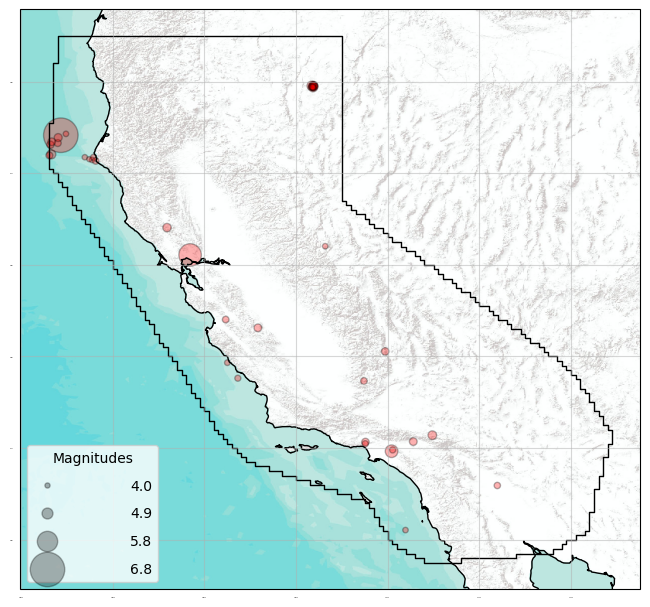

<GeoAxes: >

In [78]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2014-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2014-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)
catalog.plot(show=True)

### ETAS

In [79]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [80]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

0.17875383425174532


In [111]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.6192876


#### L-Score

In [112]:
print(QL.ell_score(fore_df= ETAS_forec,
                    cat_df = catalogEvents))

#Optional to free memory space
del ETAS_forec

-281.8713


### ETASV1.1

In [81]:
## Load ETASV1.1 model
## start date: 01 July 2012    end date: 30 June 2018
## missing days: 4      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETASV1_1_filename = '../data/ETASV1_1_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETASV1_1 = f_hdf5.load_hdf5_to_dict(ETASV1_1_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [82]:
ETASV1_1forecast = QL.combine_forecast_dataframes(ETASV1_1)
del ETASV1_1

QETASV1_1 = QL.q_score_calc(
    forecast_df=ETASV1_1forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETASV1_1)

del ETASV1_1forecast

0.006123690468261197


In [141]:
all_df = []
#Loop through the nested dictionary
for year, months in ETASV1_1.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETASV1_1_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETASV1_1

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETASV1_1_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.6353881


#### L-Score

In [142]:
print(QL.ell_score(fore_df= ETASV1_1_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETASV1_1_forec

-186.90817


### ETAS_DROneDayMd2

In [83]:
## Load ETAS_DROneDayMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 17       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd2_filename = '../data/ETAS_DROneDayMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd2_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [84]:
ETAS_DROneDayMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd2)
del ETAS_DROneDayMd2

QETAS_DROneDayMd2 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd2)

del ETAS_DROneDayMd2forecast

0.0009456186216116531


In [126]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayMd2

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.8716273


#### L-Score

In [127]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd2_forec

-177.07307


### ETAS_DROneDayMd3

In [85]:
## Load ETAS_DROneDayMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd3_filename = '../data/ETAS_DROneDayMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd3_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [86]:
ETAS_DROneDayMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd3)
del ETAS_DROneDayMd3

QETAS_DROneDayMd3 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd3)

del ETAS_DROneDayMd3forecast

0.0018023776563214785


In [123]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

5.055212


#### L-Score

In [124]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd3_forec

-180.12727


### ETAS_HWMd2

In [87]:
## Load ETAS_HWMd2 model
## start date: 01 Oct. 2012    end date: 19 Sep. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HWMd2_filename = '../data/ETAS_HWMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HWMd2 = f_hdf5.load_hdf5_to_dict(ETAS_HWMd2_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [88]:
ETAS_HWMd2forecast = QL.combine_forecast_dataframes(ETAS_HWMd2)
del ETAS_HWMd2

QETAS_HWMd2 = QL.q_score_calc(
    forecast_df=ETAS_HWMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HWMd2)

del ETAS_HWMd2forecast

0.0024495553232193124


In [153]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HWMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HWMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HWMd2

print(QL.calculate_Q_score(fore_df= ETAS_HWMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.7055646


#### L-Score

In [154]:
print(QL.ell_score(fore_df= ETAS_HWMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HWMd2_forec

-164.50772


### ETAS_HWMd3

In [89]:
## Load ETAS_HWMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HWMd3_filename = '../data/ETAS_HWMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HWMd3 = f_hdf5.load_hdf5_to_dict(ETAS_HWMd3_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [90]:
ETAS_HWMd3forecast = QL.combine_forecast_dataframes(ETAS_HWMd3)
del ETAS_HWMd3

QETAS_HWMd3 = QL.q_score_calc(
    forecast_df=ETAS_HWMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HWMd3)

del ETAS_HWMd3forecast

0.0034411621851530255


In [138]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HWMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HWMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HWMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HWMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.81535846


#### L-Score

In [139]:
print(QL.ell_score(fore_df= ETAS_HWMd3_forec,
                     cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HWMd3_forec

-161.50389


### STEPJAVA

In [91]:
## Load STEPJAVA model
## start date: 01 Sep. 2010    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
STEPJAVA_filename = '../data/STEPJAVA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEPJAVA = f_hdf5.load_hdf5_to_dict(STEPJAVA_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [92]:
STEPJAVAforecast = QL.combine_forecast_dataframes(STEPJAVA)
del STEPJAVA

QSTEPJAVA = QL.q_score_calc(
    forecast_df=STEPJAVAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEPJAVA)

del STEPJAVAforecast

0.011929259959098451


In [117]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEPJAVA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEPJAVA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del STEPJAVA

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEPJAVA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

4.6815352


#### L-Score

In [118]:
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents))

# add waterlevelto zero valued bins
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents,
                 waterlevel = 1e-6))

#Optional to free memory space
del STEPJAVA_forec

C:\Users\arjon\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


-inf


C:\Users\arjon\OneDrive\Documents\S Score\Project\src\QandL.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df_out.iloc[target_idx,6] = waterlevel


-278.74840067417153


### KJSSOneDay

In [93]:
## Load KJSSOneDay model
## start date: 01 Jan. 2009    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
KJSSOne_filename = '../data/KJSSOneDayCalifornia_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
KJSSOne = f_hdf5.load_hdf5_to_dict(KJSSOne_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [94]:
KJSSOneforecast = QL.combine_forecast_dataframes(KJSSOne)
del KJSSOne

QKJSSOne = QL.q_score_calc(
    forecast_df=KJSSOneforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QKJSSOne)

del KJSSOneforecast

0.0005502553520278112


In [114]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in KJSSOne.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
KJSSOne_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del KJSSOne
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= KJSSOne_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.3453208


#### L-Score

In [115]:
print(QL.ell_score(fore_df= KJSSOne_forec,
                        cat_df = catalogEvents))

#Optional to free memory space
del KJSSOne_forec

-207.66985


### K3Md2

In [95]:
## Load K3Md2 Model model
## start date: 01 Oct. 2012    end date: 19 Sep. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
K3Md2_filename = '../data/K3Md2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
K3Md2 = f_hdf5.load_hdf5_to_dict(K3Md2_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014') 

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [96]:
K3Md2forecast = QL.combine_forecast_dataframes(K3Md2)
del K3Md2

QK3Md2= QL.q_score_calc(
    forecast_df=K3Md2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QK3Md2)

del K3Md2forecast

0.0011467476904809437


In [156]:
all_df = []
#Loop through the nested dictionary
for year, months in K3Md2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
K3Md2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del K3Md2

print(QL.calculate_Q_score(fore_df= K3Md2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.17458114


#### L-Score

In [157]:
print(QL.ell_score(fore_df= K3Md2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del K3Md2_forec

-184.08005


### K3Md3

In [97]:
## Load K3Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
K3Md3_filename = '../data/K3Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
K3Md3 = f_hdf5.load_hdf5_to_dict(K3Md3_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [98]:
K3Md3forecast = QL.combine_forecast_dataframes(K3Md3)
del K3Md3

QK3Md3= QL.q_score_calc(
    forecast_df=K3Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QK3Md3)

del K3Md3forecast

0.0016104694547605042


In [120]:
all_df = []
#Loop through the nested dictionary
for year, months in K3Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
K3Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del K3Md3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= K3Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.082921125


#### L-Score

In [121]:
print(QL.ell_score(fore_df= K3Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del K3Md3_forec

-193.63126


### ETAS_DROneDayPPEMd2

In [99]:
## Load ETAS_DROneDayPPEMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 18      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd2_filename = '../data/ETAS_DROneDayPPEMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd2_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [100]:
ETAS_DROneDayPPEMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd2)
del ETAS_DROneDayPPEMd2

QETAS_DROneDayPPEMd2= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd2)

del ETAS_DROneDayPPEMd2forecast

0.3034539477965062


In [132]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayPPEMd2

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.58411396


#### L-Score

In [133]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd2_forec

-311.0488


### ETAS_DROneDayPPEMd3

In [101]:
## Load ETAS_DROneDayPPEMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 6      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd3_filename = '../data/ETAS_DROneDayPPEMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd3_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [102]:
ETAS_DROneDayPPEMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd3)
del ETAS_DROneDayPPEMd3

QETAS_DROneDayPPEMd3= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd3)

del ETAS_DROneDayPPEMd3forecast

0.24053012682078978


In [129]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayPPEMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.73582864


#### L-Score

In [130]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd3_forec

-289.89304


### ETAS_HW_K3_AVERAGE_Md2

In [103]:
## Load ETAS_HW_K3_AVERAGE_Md2 model
## start date: 01 Oct. 2012    end date: 19 Sep. 2016
## missing days: 1     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HW_K3_AVERAGE_Md2_filename = '../data/ETAS_HW_K3_AVERAGE_Md2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HW_K3_AVERAGE_Md2 = f_hdf5.load_hdf5_to_dict(ETAS_HW_K3_AVERAGE_Md2_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014') 

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [104]:
ETAS_HW_K3_AVERAGE_Md2forecast = QL.combine_forecast_dataframes(ETAS_HW_K3_AVERAGE_Md2)
del ETAS_HW_K3_AVERAGE_Md2

QETAS_HW_K3_AVERAGE_Md2= QL.q_score_calc(
    forecast_df=ETAS_HW_K3_AVERAGE_Md2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HW_K3_AVERAGE_Md2)

del ETAS_HW_K3_AVERAGE_Md2forecast

0.0016652903242624587


In [150]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HW_K3_AVERAGE_Md2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HW_K3_AVERAGE_Md2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HW_K3_AVERAGE_Md2

print(QL.calculate_Q_score(fore_df= ETAS_HW_K3_AVERAGE_Md2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.425735


#### L-Score

In [151]:
print(QL.ell_score(fore_df= ETAS_HW_K3_AVERAGE_Md2_forec,
                  cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HW_K3_AVERAGE_Md2_forec

-169.71646


### ETAS_HW_K3_AVERAGE_Md3

In [105]:
## Load ETAS_HW_K3_AVERAGE_Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 23      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HW_K3_AVERAGE_Md3_filename = '../data/ETAS_HW_K3_AVERAGE_Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HW_K3_AVERAGE_Md3 = f_hdf5.load_hdf5_to_dict(ETAS_HW_K3_AVERAGE_Md3_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [110]:
print(len(ETAS_HW_K3_AVERAGE_Md3forecast['date'].unique()))

352


Most models have days missing from their forecasts. This model had forecasts for only 352 days in 2014. Since in one of the days an event happened, we excluded this model for this year.

In [106]:
ETAS_HW_K3_AVERAGE_Md3forecast = QL.combine_forecast_dataframes(ETAS_HW_K3_AVERAGE_Md3)
del ETAS_HW_K3_AVERAGE_Md3

QETAS_HW_K3_AVERAGE_Md3= QL.q_score_calc(
    forecast_df=ETAS_HW_K3_AVERAGE_Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HW_K3_AVERAGE_Md3)

del ETAS_HW_K3_AVERAGE_Md3forecast

ValueError: Event space-time coordinate did not match any grid cell: {'id': b'ci37265488', 'origin_time': 1410092036570, 'latitude': 32.2121667, 'longitude': -117.6125, 'depth': 14.855, 'magnitude': 4.02, 'counts': 1, 'catalog_id': None, 'region_id': 5481, 'mag_id': 0, 'date': '2014-09-07'}

In [135]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HW_K3_AVERAGE_Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HW_K3_AVERAGE_Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HW_K3_AVERAGE_Md3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.382392


#### L-Score

In [136]:
print(QL.ell_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HW_K3_AVERAGE_Md3_forec

-168.89622


### OneDayBayesianBMA

In [111]:
## Load OneDayBayesianBMA model
## start date: 01 July 2012    end date: 07 Aug. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
OneDayBayesianBMA_filename = '../data/OneDayBayesianBMA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
OneDayBayesianBMA = f_hdf5.load_hdf5_to_dict(OneDayBayesianBMA_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [112]:
OneDayBayesianBMAforecast = QL.combine_forecast_dataframes(OneDayBayesianBMA)
del OneDayBayesianBMA

QOneDayBayesianBMA= QL.q_score_calc(
    forecast_df=OneDayBayesianBMAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QOneDayBayesianBMA)

del OneDayBayesianBMAforecast

0.006130390137703303


In [144]:
all_df = []
#Loop through the nested dictionary
for year, months in OneDayBayesianBMA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
OneDayBayesianBMA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del OneDayBayesianBMA

print(QL.calculate_Q_score(fore_df= OneDayBayesianBMA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.6337066


#### L-Score

In [145]:
print(QL.ell_score(fore_df= OneDayBayesianBMA_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del OneDayBayesianBMA_forec

-186.91855


### OneDayBayesianSeqBMA

In [113]:
## Load OneDayBayesianSeqBMA model
## start date: 01 July 2012    end date: 07 Aug. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
OneDayBayesianSeqBMA_filename = '../data/OneDayBayesianSeqBMA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
OneDayBayesianSeqBMA = f_hdf5.load_hdf5_to_dict(OneDayBayesianSeqBMA_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [114]:
OneDayBayesianSeqBMAforecast = QL.combine_forecast_dataframes(OneDayBayesianSeqBMA)
del OneDayBayesianSeqBMA

QOneDayBayesianSeqBMA= QL.q_score_calc(
    forecast_df=OneDayBayesianSeqBMAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QOneDayBayesianSeqBMA)

del OneDayBayesianSeqBMAforecast

0.006128728725082918


In [147]:
all_df = []
#Loop through the nested dictionary
for year, months in OneDayBayesianSeqBMA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
OneDayBayesianSeqBMA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del OneDayBayesianSeqBMA

print(QL.calculate_Q_score(fore_df= OneDayBayesianSeqBMA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.6341755


#### L-Score

In [148]:
print(QL.ell_score(fore_df= OneDayBayesianSeqBMA_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del OneDayBayesianSeqBMA_forec

-186.91606


## 2015

Fetched ComCat catalog in 1.8220577239990234 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2015-01-01 08:43:07.260000+00:00
End Date: 2015-12-31 17:59:26.740000+00:00
Min Latitude: 31.5081667 and Max Latitude: 42.5725
Min Longitude: -125.3966667 and Max Longitude: -113.1896667
Min Magnitude: 2.5
Found 1242 events in the ComCat catalog.

        Name: None

        Start Date: 2015-01-04 03:18:09.480000+00:00
        End Date: 2015-12-30 01:48:57.310000+00:00

        Latitude: (31.6135, 41.9006)
        Longitude: (-125.3966667, -115.2085)

        Min Mw: 3.98
        Max Mw: 5.72

        Event Count: 38
        


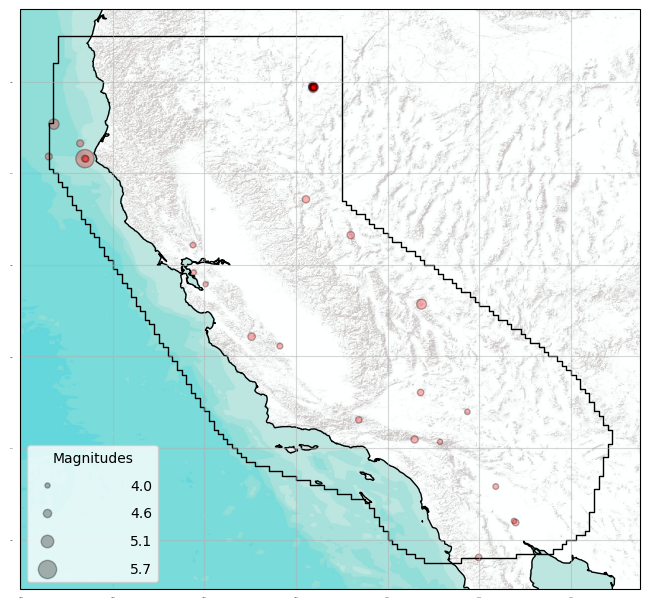

<GeoAxes: >

In [115]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2015-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2015-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)
catalog.plot(show=True)

### ETAS

In [116]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [117]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

0.29082282908766605


In [160]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.754938


#### L-Score

In [161]:
print(QL.ell_score(fore_df= ETAS_forec,
                        cat_df = catalogEvents))

#Optional to free memory space
del ETAS_forec

-246.74518


### ETASV1.1

In [118]:
## Load ETASV1.1 model
## start date: 01 July 2012    end date: 30 June 2018
## missing days: 4      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETASV1_1_filename = '../data/ETASV1_1_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETASV1_1 = f_hdf5.load_hdf5_to_dict(ETASV1_1_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [119]:
ETASV1_1forecast = QL.combine_forecast_dataframes(ETASV1_1)
del ETASV1_1

QETASV1_1 = QL.q_score_calc(
    forecast_df=ETASV1_1forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETASV1_1)

del ETASV1_1forecast

0.09413565917342531


In [190]:
all_df = []
#Loop through the nested dictionary
for year, months in ETASV1_1.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETASV1_1_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETASV1_1

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETASV1_1_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.87711674


#### L-Score

In [191]:
print(QL.ell_score(fore_df= ETASV1_1_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETASV1_1_forec

-154.1322


### ETAS_DROneDayMd2

In [120]:
## Load ETAS_DROneDayMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 17       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd2_filename = '../data/ETAS_DROneDayMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd2_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [121]:
ETAS_DROneDayMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd2)
del ETAS_DROneDayMd2

QETAS_DROneDayMd2 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd2)

del ETAS_DROneDayMd2forecast

0.022851870381144584


In [175]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayMd2

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.8297951


#### L-Score

In [176]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd2_forec

-136.95143


### ETAS_DROneDayMd3

In [122]:
## Load ETAS_DROneDayMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd3_filename = '../data/ETAS_DROneDayMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd3_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [123]:
ETAS_DROneDayMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd3)
del ETAS_DROneDayMd3

QETAS_DROneDayMd3 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd3)

del ETAS_DROneDayMd3forecast

0.05372616538874028


In [172]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.67174524


#### L-Score

In [173]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd3_forec

-137.0457


### ETAS_HWMd2

In [124]:
## Load ETAS_HWMd2 model
## start date: 01 Oct. 2012    end date: 19 Sep. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HWMd2_filename = '../data/ETAS_HWMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HWMd2 = f_hdf5.load_hdf5_to_dict(ETAS_HWMd2_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [125]:
ETAS_HWMd2forecast = QL.combine_forecast_dataframes(ETAS_HWMd2)
del ETAS_HWMd2

QETAS_HWMd2 = QL.q_score_calc(
    forecast_df=ETAS_HWMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HWMd2)

del ETAS_HWMd2forecast

0.07165318425681712


In [202]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HWMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HWMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HWMd2

print(QL.calculate_Q_score(fore_df= ETAS_HWMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.20040658


#### L-Score

In [203]:
print(QL.ell_score(fore_df= ETAS_HWMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HWMd2_forec

-139.4583


### ETAS_HWMd3

In [126]:
## Load ETAS_HWMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HWMd3_filename = '../data/ETAS_HWMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HWMd3 = f_hdf5.load_hdf5_to_dict(ETAS_HWMd3_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [127]:
ETAS_HWMd3forecast = QL.combine_forecast_dataframes(ETAS_HWMd3)
del ETAS_HWMd3

QETAS_HWMd3 = QL.q_score_calc(
    forecast_df=ETAS_HWMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HWMd3)

del ETAS_HWMd3forecast

0.11708232518780792


In [187]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HWMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HWMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HWMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HWMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.37064815


#### L-Score

In [188]:
print(QL.ell_score(fore_df= ETAS_HWMd3_forec,
                     cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HWMd3_forec

-134.88109


### STEPJAVA

In [128]:
## Load STEPJAVA model
## start date: 01 Sep. 2010    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
STEPJAVA_filename = '../data/STEPJAVA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEPJAVA = f_hdf5.load_hdf5_to_dict(STEPJAVA_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [129]:
STEPJAVAforecast = QL.combine_forecast_dataframes(STEPJAVA)
del STEPJAVA

QSTEPJAVA = QL.q_score_calc(
    forecast_df=STEPJAVAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEPJAVA)

del STEPJAVAforecast

0.0


In [166]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEPJAVA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEPJAVA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del STEPJAVA

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEPJAVA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.0


#### L-Score

In [167]:
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents))

# add waterlevelto zero valued bins
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents,
                 waterlevel = 1e-6))

#Optional to free memory space
del STEPJAVA_forec

C:\Users\arjon\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


-inf


C:\Users\arjon\OneDrive\Documents\S Score\Project\src\QandL.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df_out.iloc[target_idx,6] = waterlevel


-212.33032553415916


### KJSSOneDay

In [130]:
## Load KJSSOneDay model
## start date: 01 Jan. 2009    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
KJSSOne_filename = '../data/KJSSOneDayCalifornia_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
KJSSOne = f_hdf5.load_hdf5_to_dict(KJSSOne_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [131]:
KJSSOneforecast = QL.combine_forecast_dataframes(KJSSOne)
del KJSSOne

QKJSSOne = QL.q_score_calc(
    forecast_df=KJSSOneforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QKJSSOne)

del KJSSOneforecast

0.08814812344667218


In [163]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in KJSSOne.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
KJSSOne_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del KJSSOne
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= KJSSOne_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.5082199


#### L-Score

In [164]:
print(QL.ell_score(fore_df= KJSSOne_forec,
                        cat_df = catalogEvents))

#Optional to free memory space
del KJSSOne_forec

-181.4761


### K3Md2

In [132]:
## Load K3Md2 Model model
## start date: 01 Oct. 2012    end date: 19 Sep. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
K3Md2_filename = '../data/K3Md2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
K3Md2 = f_hdf5.load_hdf5_to_dict(K3Md2_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015') 

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [133]:
K3Md2forecast = QL.combine_forecast_dataframes(K3Md2)
del K3Md2

QK3Md2= QL.q_score_calc(
    forecast_df=K3Md2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QK3Md2)

del K3Md2forecast

0.1916648108817381


In [205]:
all_df = []
#Loop through the nested dictionary
for year, months in K3Md2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
K3Md2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del K3Md2

print(QL.calculate_Q_score(fore_df= K3Md2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.08069553


#### L-Score

In [206]:
print(QL.ell_score(fore_df= K3Md2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del K3Md2_forec

-159.33887


### K3Md3

In [134]:
## Load K3Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
K3Md3_filename = '../data/K3Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
K3Md3 = f_hdf5.load_hdf5_to_dict(K3Md3_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [135]:
K3Md3forecast = QL.combine_forecast_dataframes(K3Md3)
del K3Md3

QK3Md3= QL.q_score_calc(
    forecast_df=K3Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QK3Md3)

del K3Md3forecast

0.044566946904249144


In [169]:
all_df = []
#Loop through the nested dictionary
for year, months in K3Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
K3Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del K3Md3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= K3Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.054896966


#### L-Score

In [170]:
print(QL.ell_score(fore_df= K3Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del K3Md3_forec

-161.37215


### ETAS_DROneDayPPEMd2

In [136]:
## Load ETAS_DROneDayPPEMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 18      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd2_filename = '../data/ETAS_DROneDayPPEMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd2_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [137]:
ETAS_DROneDayPPEMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd2)
del ETAS_DROneDayPPEMd2

QETAS_DROneDayPPEMd2= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd2)

del ETAS_DROneDayPPEMd2forecast

1.7343602262200084


In [181]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayPPEMd2

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.8456281


#### L-Score

In [182]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd2_forec

-253.15714


### ETAS_DROneDayPPEMd3

In [138]:
## Load ETAS_DROneDayPPEMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 6      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd3_filename = '../data/ETAS_DROneDayPPEMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd3_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [139]:
ETAS_DROneDayPPEMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd3)
del ETAS_DROneDayPPEMd3

QETAS_DROneDayPPEMd3= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd3)

del ETAS_DROneDayPPEMd3forecast

1.5782305823810692


In [178]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayPPEMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.7088698


#### L-Score

In [179]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd3_forec

-232.92433


### ETAS_HW_K3_AVERAGE_Md2

In [140]:
## Load ETAS_HW_K3_AVERAGE_Md2 model
## start date: 01 Oct. 2012    end date: 19 Sep. 2016
## missing days: 1     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HW_K3_AVERAGE_Md2_filename = '../data/ETAS_HW_K3_AVERAGE_Md2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HW_K3_AVERAGE_Md2 = f_hdf5.load_hdf5_to_dict(ETAS_HW_K3_AVERAGE_Md2_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015') 

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [141]:
ETAS_HW_K3_AVERAGE_Md2forecast = QL.combine_forecast_dataframes(ETAS_HW_K3_AVERAGE_Md2)
del ETAS_HW_K3_AVERAGE_Md2

QETAS_HW_K3_AVERAGE_Md2= QL.q_score_calc(
    forecast_df=ETAS_HW_K3_AVERAGE_Md2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HW_K3_AVERAGE_Md2)

del ETAS_HW_K3_AVERAGE_Md2forecast

0.1048672530030116


In [199]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HW_K3_AVERAGE_Md2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HW_K3_AVERAGE_Md2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HW_K3_AVERAGE_Md2

print(QL.calculate_Q_score(fore_df= ETAS_HW_K3_AVERAGE_Md2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.13933264


#### L-Score

In [200]:
print(QL.ell_score(fore_df= ETAS_HW_K3_AVERAGE_Md2_forec,
                  cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HW_K3_AVERAGE_Md2_forec

-146.63353


### ETAS_HW_K3_AVERAGE_Md3

In [142]:
## Load ETAS_HW_K3_AVERAGE_Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 23      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HW_K3_AVERAGE_Md3_filename = '../data/ETAS_HW_K3_AVERAGE_Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HW_K3_AVERAGE_Md3 = f_hdf5.load_hdf5_to_dict(ETAS_HW_K3_AVERAGE_Md3_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [143]:
ETAS_HW_K3_AVERAGE_Md3forecast = QL.combine_forecast_dataframes(ETAS_HW_K3_AVERAGE_Md3)
del ETAS_HW_K3_AVERAGE_Md3

QETAS_HW_K3_AVERAGE_Md3= QL.q_score_calc(
    forecast_df=ETAS_HW_K3_AVERAGE_Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HW_K3_AVERAGE_Md3)

del ETAS_HW_K3_AVERAGE_Md3forecast

0.08979964923295619


In [184]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HW_K3_AVERAGE_Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HW_K3_AVERAGE_Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HW_K3_AVERAGE_Md3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.20275785


#### L-Score

In [185]:
print(QL.ell_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HW_K3_AVERAGE_Md3_forec

-143.15112


### OneDayBayesianBMA

In [144]:
## Load OneDayBayesianBMA model
## start date: 01 July 2012    end date: 07 Aug. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
OneDayBayesianBMA_filename = '../data/OneDayBayesianBMA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
OneDayBayesianBMA = f_hdf5.load_hdf5_to_dict(OneDayBayesianBMA_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [145]:
OneDayBayesianBMAforecast = QL.combine_forecast_dataframes(OneDayBayesianBMA)
del OneDayBayesianBMA

QOneDayBayesianBMA= QL.q_score_calc(
    forecast_df=OneDayBayesianBMAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QOneDayBayesianBMA)

del OneDayBayesianBMAforecast

0.09413565917342531


In [193]:
all_df = []
#Loop through the nested dictionary
for year, months in OneDayBayesianBMA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
OneDayBayesianBMA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del OneDayBayesianBMA

print(QL.calculate_Q_score(fore_df= OneDayBayesianBMA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.87711674


#### L-Score

In [194]:
print(QL.ell_score(fore_df= OneDayBayesianBMA_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del OneDayBayesianBMA_forec

-154.1322


### OneDayBayesianSeqBMA

In [146]:
## Load OneDayBayesianSeqBMA model
## start date: 01 July 2012    end date: 07 Aug. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
OneDayBayesianSeqBMA_filename = '../data/OneDayBayesianSeqBMA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
OneDayBayesianSeqBMA = f_hdf5.load_hdf5_to_dict(OneDayBayesianSeqBMA_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [147]:
OneDayBayesianSeqBMAforecast = QL.combine_forecast_dataframes(OneDayBayesianSeqBMA)
del OneDayBayesianSeqBMA

QOneDayBayesianSeqBMA= QL.q_score_calc(
    forecast_df=OneDayBayesianSeqBMAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QOneDayBayesianSeqBMA)

del OneDayBayesianSeqBMAforecast

0.09413565917342531


In [196]:
all_df = []
#Loop through the nested dictionary
for year, months in OneDayBayesianSeqBMA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
OneDayBayesianSeqBMA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del OneDayBayesianSeqBMA

print(QL.calculate_Q_score(fore_df= OneDayBayesianSeqBMA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.87711674


#### L-Score

In [197]:
print(QL.ell_score(fore_df= OneDayBayesianSeqBMA_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del OneDayBayesianSeqBMA_forec

-154.1322


## 2016

Fetched ComCat catalog in 2.699678897857666 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2016-01-01 13:40:30.650000+00:00
End Date: 2016-12-31 23:48:13.270000+00:00
Min Latitude: 31.5016667 and Max Latitude: 42.444
Min Longitude: -125.3781667 and Max Longitude: -113.1156
Min Magnitude: 2.5
Found 1100 events in the ComCat catalog.

        Name: None

        Start Date: 2016-01-02 05:11:46.620000+00:00
        End Date: 2016-12-28 09:13:47.243000+00:00

        Latitude: (32.9583333, 41.8685)
        Longitude: (-125.3781667, -115.701)

        Min Mw: 3.95
        Max Mw: 5.6

        Event Count: 36
        


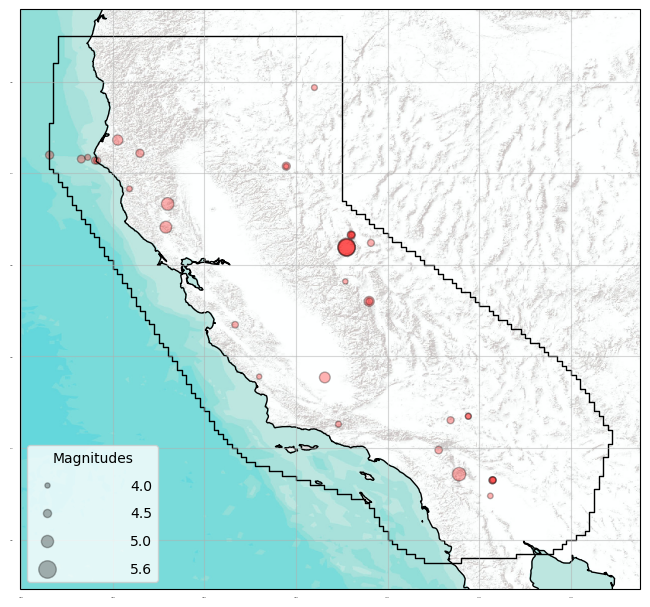

<GeoAxes: >

In [2]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2016-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2016-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)
catalog.plot(show=True)

### ETAS

In [149]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95
#
# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [150]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

0.30275190834865995


In [209]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.4113102


#### L-Score

In [210]:
print(QL.ell_score(fore_df= ETAS_forec,
                        cat_df = catalogEvents))

#Optional to free memory space
del ETAS_forec

-246.06372


### ETASV1.1

In [151]:
## Load ETASV1.1 model
## start date: 01 July 2012    end date: 30 June 2018
## missing days: 4      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETASV1_1_filename = '../data/ETASV1_1_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETASV1_1 = f_hdf5.load_hdf5_to_dict(ETASV1_1_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [154]:
len(ETASV1_1forecast['date'].unique())

362

Most models have days missing from their forecasts. This model had forecasts for only 362 days in 2016. Since in one of the days an event happened, we excluded this model for this year.

In [152]:
ETASV1_1forecast = QL.combine_forecast_dataframes(ETASV1_1)
del ETASV1_1

QETASV1_1 = QL.q_score_calc(
    forecast_df=ETASV1_1forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETASV1_1)

del ETASV1_1forecast

ValueError: Event space-time coordinate did not match any grid cell: {'id': b'ci37701544', 'origin_time': 1474946638150, 'latitude': 33.2998333, 'longitude': -115.7123333, 'depth': 4.84, 'magnitude': 4.33, 'counts': 1, 'catalog_id': None, 'region_id': 6663, 'mag_id': 3, 'date': '2016-09-27'}

In [239]:
all_df = []
#Loop through the nested dictionary
for year, months in ETASV1_1.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETASV1_1_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETASV1_1

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETASV1_1_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.740312


#### L-Score

In [240]:
print(QL.ell_score(fore_df= ETASV1_1_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETASV1_1_forec

-167.68134


### ETAS_DROneDayMd2

In [155]:
## Load ETAS_DROneDayMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 17       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd2_filename = '../data/ETAS_DROneDayMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd2_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [156]:
ETAS_DROneDayMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd2)
del ETAS_DROneDayMd2

QETAS_DROneDayMd2 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd2)

del ETAS_DROneDayMd2forecast

0.002368555509594817


In [224]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayMd2

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.1549268


#### L-Score

In [225]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd2_forec

-158.01955


### ETAS_DROneDayMd3

In [157]:
## Load ETAS_DROneDayMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd3_filename = '../data/ETAS_DROneDayMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd3_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [159]:
len(ETAS_DROneDayMd3forecast['date'].unique())

362

Most models have days missing from their forecasts. This model had forecasts for only 362 days in 2016. Since in one of the days an event happened, we excluded this model for this year.

In [158]:
ETAS_DROneDayMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd3)
del ETAS_DROneDayMd3

QETAS_DROneDayMd3 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd3)

del ETAS_DROneDayMd3forecast

ValueError: Event space-time coordinate did not match any grid cell: {'id': b'ci37701544', 'origin_time': 1474946638150, 'latitude': 33.2998333, 'longitude': -115.7123333, 'depth': 4.84, 'magnitude': 4.33, 'counts': 1, 'catalog_id': None, 'region_id': 6663, 'mag_id': 3, 'date': '2016-09-27'}

In [221]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.7373854


#### L-Score

In [222]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd3_forec

-158.25244


### ETAS_HWMd3

In [160]:
## Load ETAS_HWMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HWMd3_filename = '../data/ETAS_HWMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HWMd3 = f_hdf5.load_hdf5_to_dict(ETAS_HWMd3_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [162]:
len(ETAS_HWMd3forecast['date'].unique())

362

Most models have days missing from their forecasts. This model had forecasts for only 362 days in 2016. Since in one of the days an event happened, we excluded this model for this year.

In [161]:
ETAS_HWMd3forecast = QL.combine_forecast_dataframes(ETAS_HWMd3)
del ETAS_HWMd3

QETAS_HWMd3 = QL.q_score_calc(
    forecast_df=ETAS_HWMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HWMd3)

del ETAS_HWMd3forecast

ValueError: Event space-time coordinate did not match any grid cell: {'id': b'ci37701544', 'origin_time': 1474946638150, 'latitude': 33.2998333, 'longitude': -115.7123333, 'depth': 4.84, 'magnitude': 4.33, 'counts': 1, 'catalog_id': None, 'region_id': 6663, 'mag_id': 3, 'date': '2016-09-27'}

In [236]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HWMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HWMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HWMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HWMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.9143507


#### L-Score

In [237]:
print(QL.ell_score(fore_df= ETAS_HWMd3_forec,
                     cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HWMd3_forec

-159.54663


### STEPJAVA

In [163]:
## Load STEPJAVA model
## start date: 01 Sep. 2010    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
STEPJAVA_filename = '../data/STEPJAVA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEPJAVA = f_hdf5.load_hdf5_to_dict(STEPJAVA_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [164]:
STEPJAVAforecast = QL.combine_forecast_dataframes(STEPJAVA)
del STEPJAVA

QSTEPJAVA = QL.q_score_calc(
    forecast_df=STEPJAVAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEPJAVA)

del STEPJAVAforecast

0.001157496590221552


In [215]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEPJAVA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEPJAVA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del STEPJAVA

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEPJAVA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.9024143


#### L-Score

In [216]:
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents))

# add waterlevelto zero valued bins
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents,
                 waterlevel = 1e-6))

#Optional to free memory space
del STEPJAVA_forec

C:\Users\arjon\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


-inf


C:\Users\arjon\OneDrive\Documents\S Score\Project\src\QandL.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df_out.iloc[target_idx,6] = waterlevel


-184.96761668093234


### KJSSOneDay

In [165]:
## Load KJSSOneDay model
## start date: 01 Jan. 2009    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
KJSSOne_filename = '../data/KJSSOneDayCalifornia_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
KJSSOne = f_hdf5.load_hdf5_to_dict(KJSSOne_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [166]:
KJSSOneforecast = QL.combine_forecast_dataframes(KJSSOne)
del KJSSOne

QKJSSOne = QL.q_score_calc(
    forecast_df=KJSSOneforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QKJSSOne)

del KJSSOneforecast

0.005499146163838795


In [212]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in KJSSOne.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
KJSSOne_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del KJSSOne
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= KJSSOne_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.5418363


#### L-Score

In [213]:
print(QL.ell_score(fore_df= KJSSOne_forec,
                        cat_df = catalogEvents))

#Optional to free memory space
del KJSSOne_forec

-224.14252


### K3Md3

In [167]:
## Load K3Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
K3Md3_filename = '../data/K3Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
K3Md3 = f_hdf5.load_hdf5_to_dict(K3Md3_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [169]:
len(K3Md3forecast['date'].unique())

362

Most models have days missing from their forecasts. This model had forecasts for only 362 days in 2016. Since in one of the days an event happened, we excluded this model for this year.

In [168]:
K3Md3forecast = QL.combine_forecast_dataframes(K3Md3)
del K3Md3

QK3Md3= QL.q_score_calc(
    forecast_df=K3Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QK3Md3)

del K3Md3forecast

ValueError: Event space-time coordinate did not match any grid cell: {'id': b'ci37701544', 'origin_time': 1474946638150, 'latitude': 33.2998333, 'longitude': -115.7123333, 'depth': 4.84, 'magnitude': 4.33, 'counts': 1, 'catalog_id': None, 'region_id': 6663, 'mag_id': 3, 'date': '2016-09-27'}

In [218]:
all_df = []
#Loop through the nested dictionary
for year, months in K3Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
K3Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del K3Md3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= K3Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))


0.65831786


#### L-Score

In [219]:
print(QL.ell_score(fore_df= K3Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del K3Md3_forec

-206.37994


### ETAS_DROneDayPPEMd2

In [170]:
## Load ETAS_DROneDayPPEMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 18      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd2_filename = '../data/ETAS_DROneDayPPEMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd2_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [171]:
ETAS_DROneDayPPEMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd2)
del ETAS_DROneDayPPEMd2

QETAS_DROneDayPPEMd2= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd2)

del ETAS_DROneDayPPEMd2forecast

0.24422325102001738


In [230]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayPPEMd2

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.23653539


#### L-Score

In [231]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd2_forec

-248.94925


### ETAS_DROneDayPPEMd3

In [172]:
## Load ETAS_DROneDayPPEMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 6      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd3_filename = '../data/ETAS_DROneDayPPEMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd3_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [174]:
len(ETAS_DROneDayPPEMd3forecast['date'].unique())

361

Most models have days missing from their forecasts. This model had forecasts for only 361 days in 2016. Since in one of the days an event happened, we excluded this model for this year.

In [173]:
ETAS_DROneDayPPEMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd3)
del ETAS_DROneDayPPEMd3

QETAS_DROneDayPPEMd3= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd3)

del ETAS_DROneDayPPEMd3forecast

ValueError: Event space-time coordinate did not match any grid cell: {'id': b'ci37700296', 'origin_time': 1474900268040, 'latitude': 33.2976667, 'longitude': -115.7136667, 'depth': 2.2, 'magnitude': 4.32, 'counts': 1, 'catalog_id': None, 'region_id': 6663, 'mag_id': 3, 'date': '2016-09-26'}

In [227]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayPPEMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.15363483


#### L-Score

In [228]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd3_forec

-234.2545


### ETAS_HW_K3_AVERAGE_Md3

In [3]:
## Load ETAS_HW_K3_AVERAGE_Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 23      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HW_K3_AVERAGE_Md3_filename = '../data/ETAS_HW_K3_AVERAGE_Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HW_K3_AVERAGE_Md3 = f_hdf5.load_hdf5_to_dict(ETAS_HW_K3_AVERAGE_Md3_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [5]:
len(ETAS_HW_K3_AVERAGE_Md3forecast['date'].unique())

360

Most models have days missing from their forecasts. This model had forecasts for only 360 days in 2016. Since in one of the days an event happened, we excluded this model for this year.

In [4]:
ETAS_HW_K3_AVERAGE_Md3forecast = QL.combine_forecast_dataframes(ETAS_HW_K3_AVERAGE_Md3)
del ETAS_HW_K3_AVERAGE_Md3

QETAS_HW_K3_AVERAGE_Md3= QL.q_score_calc(
    forecast_df=ETAS_HW_K3_AVERAGE_Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HW_K3_AVERAGE_Md3)

del ETAS_HW_K3_AVERAGE_Md3forecast

ValueError: Event space-time coordinate did not match any grid cell: {'id': b'ci37700296', 'origin_time': 1474900268040, 'latitude': 33.2976667, 'longitude': -115.7136667, 'depth': 2.2, 'magnitude': 4.32, 'counts': 1, 'catalog_id': None, 'region_id': 6663, 'mag_id': 3, 'date': '2016-09-26'}

In [233]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HW_K3_AVERAGE_Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HW_K3_AVERAGE_Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HW_K3_AVERAGE_Md3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.5636597


#### L-Score

In [234]:
print(QL.ell_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HW_K3_AVERAGE_Md3_forec

-172.85724


## 2017

Fetched ComCat catalog in 2.2489004135131836 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2017-01-01 00:04:56.020000+00:00
End Date: 2017-12-31 19:49:06.270000+00:00
Min Latitude: 31.5071667 and Max Latitude: 42.1398333
Min Longitude: -125.3621667 and Max Longitude: -113.1378333
Min Magnitude: 2.5
Found 961 events in the ComCat catalog.

        Name: None

        Start Date: 2017-02-21 00:57:52.710000+00:00
        End Date: 2017-12-14 04:57:18.580000+00:00

        Latitude: (32.225, 41.0753333)
        Longitude: (-125.3303333, -115.2278333)

        Min Mw: 3.95
        Max Mw: 5.08

        Event Count: 18
        


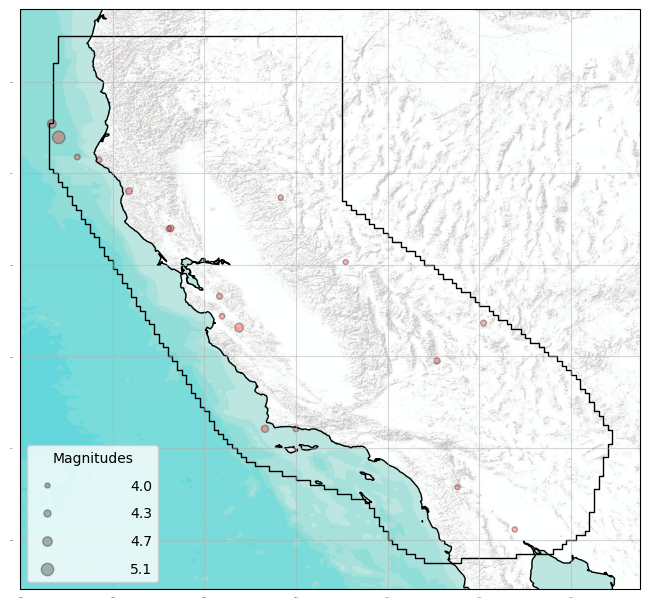

<GeoAxes: >

In [6]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2017-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2017-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)
catalog.plot(show=True)

### ETAS

In [7]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [8]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

2.6634935860425024


In [243]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.5255775


#### L-Score

In [244]:
print(QL.ell_score(fore_df= ETAS_forec,
                    cat_df = catalogEvents))

#Optional to free memory space
del ETAS_forec

-147.35815


### ETASV1.1

In [9]:
## Load ETASV1.1 model
## start date: 01 July 2012    end date: 30 June 2018
## missing days: 4      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETASV1_1_filename = '../data/ETASV1_1_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETASV1_1 = f_hdf5.load_hdf5_to_dict(ETASV1_1_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [10]:
ETASV1_1forecast = QL.combine_forecast_dataframes(ETASV1_1)
del ETASV1_1

QETASV1_1 = QL.q_score_calc(
    forecast_df=ETASV1_1forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETASV1_1)

del ETASV1_1forecast

1.9520854235092417


In [285]:
all_df = []
#Loop through the nested dictionary
for year, months in ETASV1_1.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETASV1_1_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETASV1_1

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETASV1_1_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.2102718


#### L-Score

In [286]:
print(QL.ell_score(fore_df= ETASV1_1_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETASV1_1_forec

-113.57508


### ETAS_DROneDayMd2

In [11]:
## Load ETAS_DROneDayMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 17       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd2_filename = '../data/ETAS_DROneDayMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd2_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [12]:
ETAS_DROneDayMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd2)
del ETAS_DROneDayMd2

QETAS_DROneDayMd2 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd2)

del ETAS_DROneDayMd2forecast

1.4554528151682466


In [267]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayMd2

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.8233087


#### L-Score

In [268]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd2_forec

-101.22794


### ETAS_DROneDayMd3

In [13]:
## Load ETAS_DROneDayMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd3_filename = '../data/ETAS_DROneDayMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd3_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [14]:
ETAS_DROneDayMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd3)
del ETAS_DROneDayMd3

QETAS_DROneDayMd3 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd3)

del ETAS_DROneDayMd3forecast

3.0605517148057646


In [261]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.2654457


#### L-Score

In [262]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd3_forec

-100.63479


### ETAS_DROneDayMd2.95

In [15]:
## Load ETAS_DROneDayMd2_95 model
## start date: 01 July 2016    end date: 30 June 2018
## missing days: 18       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd2_95_filename = '../data/ETAS_DROneDayMd2.95_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd2_95 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd2_95_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [17]:
len(ETAS_DROneDayMd2_95forecast['date'].unique())

351

Most models have days missing from their forecasts. This model had forecasts for only 351 days in 2017. Since in one of the days an event happened, we excluded this model for this year.

In [16]:
ETAS_DROneDayMd2_95forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd2_95)
del ETAS_DROneDayMd2_95

QETAS_DROneDayMd2_95 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd2_95forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd2_95)

del ETAS_DROneDayMd2_95forecast

ValueError: Event space-time coordinate did not match any grid cell: {'id': b'nc72906781', 'origin_time': 1507596798270, 'latitude': 37.3135, 'longitude': -121.672, 'depth': 9.69, 'magnitude': 4.09, 'counts': 1, 'catalog_id': None, 'region_id': 2117, 'mag_id': 1, 'date': '2017-10-10'}

In [264]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd2_95.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd2_95_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayMd2_95

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd2_95_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.3383002


#### L-Score

In [265]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd2_95_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd2_95_forec

-99.53112


### ETASSYN_DROneDayMd2.95

In [18]:
## Load ETASSYN_DROneDayMd2.95 model
## start date: 01 July 2016    end date: 30 June 2018
## missing days: 11      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETASSYN_DROneDayMd2_95_filename = '../data/ETASSYN_DROneDayMd2.95_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETASSYN_DROneDayMd2_95 = f_hdf5.load_hdf5_to_dict(ETASSYN_DROneDayMd2_95_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [19]:
ETASSYN_DROneDayMd2_95forecast = QL.combine_forecast_dataframes(ETASSYN_DROneDayMd2_95)
del ETASSYN_DROneDayMd2_95

QETASSYN_DROneDayMd2_95 = QL.q_score_calc(
    forecast_df=ETASSYN_DROneDayMd2_95forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETASSYN_DROneDayMd2_95)

del ETASSYN_DROneDayMd2_95forecast

3.3299567420982625


In [276]:
all_df = []
#Loop through the nested dictionary
for year, months in ETASSYN_DROneDayMd2_95.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETASSYN_DROneDayMd2_95_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETASSYN_DROneDayMd2_95

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETASSYN_DROneDayMd2_95_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.942039


#### L-Score

In [277]:
print(QL.ell_score(fore_df= ETASSYN_DROneDayMd2_95_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETASSYN_DROneDayMd2_95_forec

-99.93555


### ETAS_HWMd3

In [20]:
## Load ETAS_HWMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HWMd3_filename = '../data/ETAS_HWMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HWMd3 = f_hdf5.load_hdf5_to_dict(ETAS_HWMd3_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [21]:
ETAS_HWMd3forecast = QL.combine_forecast_dataframes(ETAS_HWMd3)
del ETAS_HWMd3

QETAS_HWMd3 = QL.q_score_calc(
    forecast_df=ETAS_HWMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HWMd3)

del ETAS_HWMd3forecast

0.3972202590409298


In [282]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HWMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HWMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HWMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HWMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.6154245


#### L-Score

In [283]:
print(QL.ell_score(fore_df= ETAS_HWMd3_forec,
                     cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HWMd3_forec

-105.5217


### GSF_ISO

In [22]:
## Load GSF_ISO model
## start date: 01 Oct. 2016    end date: 30 June 2018
## missing days: 1        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ISO_filename = '../data/GSF_ISO_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ISO = f_hdf5.load_hdf5_to_dict(ISO_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [23]:
ISOforecast = QL.combine_forecast_dataframes(ISO)
del ISO

QISO = QL.q_score_calc(
    forecast_df=ISOforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QISO)

del ISOforecast

0.5674163326255515


In [252]:
all_df = []
#Loop through the nested dictionary
for year, months in ISO.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ISO_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ISO

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ISO_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.9367224


#### L-Score

In [253]:
print(QL.ell_score(fore_df= ISO_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ISO_forec

-144.61604


### GSF_ANISO

In [24]:
## Load GSF_ANISO model
## start date: 01 Oct. 2016    end date: 30 June 2018
## missing days: 1        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ANISO_filename = '../data/GSF_ANISO_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ANISO = f_hdf5.load_hdf5_to_dict(ANISO_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [25]:
ANISOforecast = QL.combine_forecast_dataframes(ANISO)
del ANISO

QANISO = QL.q_score_calc(
    forecast_df=ANISOforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QANISO)

del ANISOforecast

0.3111904325549487


In [255]:
all_df = []
#Loop through the nested dictionary
for year, months in ANISO.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ANISO_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ANISO

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ANISO_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.7680183


#### L-Score

In [256]:
print(QL.ell_score(fore_df= ANISO_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ANISO_forec

-134.8453


### STEPJAVA

In [26]:
## Load STEPJAVA model
## start date: 01 Sep. 2010    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
STEPJAVA_filename = '../data/STEPJAVA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEPJAVA = f_hdf5.load_hdf5_to_dict(STEPJAVA_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [27]:
STEPJAVAforecast = QL.combine_forecast_dataframes(STEPJAVA)
del STEPJAVA

QSTEPJAVA = QL.q_score_calc(
    forecast_df=STEPJAVAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEPJAVA)

del STEPJAVAforecast

0.0


In [249]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEPJAVA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEPJAVA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del STEPJAVA

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEPJAVA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.0


#### L-Score

In [250]:
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents))

# add waterlevelto zero valued bins
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents,
                 waterlevel = 1e-6))

#Optional to free memory space
del STEPJAVA_forec

C:\Users\arjon\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


-inf


C:\Users\arjon\OneDrive\Documents\S Score\Project\src\QandL.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df_out.iloc[target_idx,6] = waterlevel


-133.11524686813593


### KJSSOneDay

In [28]:
## Load KJSSOneDay model
## start date: 01 Jan. 2009    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
KJSSOne_filename = '../data/KJSSOneDayCalifornia_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
KJSSOne = f_hdf5.load_hdf5_to_dict(KJSSOne_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [29]:
KJSSOneforecast = QL.combine_forecast_dataframes(KJSSOne)
del KJSSOne

QKJSSOne = QL.q_score_calc(
    forecast_df=KJSSOneforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QKJSSOne)

del KJSSOneforecast

1.46000075571411


In [246]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in KJSSOne.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
KJSSOne_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del KJSSOne
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= KJSSOne_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.37769166


#### L-Score

In [247]:
print(QL.ell_score(fore_df= KJSSOne_forec,
                        cat_df = catalogEvents))

#Optional to free memory space
del KJSSOne_forec

-112.88315


### K3Md3

In [30]:
## Load K3Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
K3Md3_filename = '../data/K3Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
K3Md3 = f_hdf5.load_hdf5_to_dict(K3Md3_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [31]:
K3Md3forecast = QL.combine_forecast_dataframes(K3Md3)
del K3Md3

QK3Md3= QL.q_score_calc(
    forecast_df=K3Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QK3Md3)

del K3Md3forecast

0.1564681491804305


In [258]:
all_df = []
#Loop through the nested dictionary
for year, months in K3Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
K3Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del K3Md3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= K3Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.1325039


#### L-Score

In [259]:
print(QL.ell_score(fore_df= K3Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del K3Md3_forec

-134.32376


### ETAS_DROneDayPPEMd2

In [32]:
## Load ETAS_DROneDayPPEMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 18      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd2_filename = '../data/ETAS_DROneDayPPEMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd2_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [33]:
ETAS_DROneDayPPEMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd2)
del ETAS_DROneDayPPEMd2

QETAS_DROneDayPPEMd2= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd2)

del ETAS_DROneDayPPEMd2forecast

0.6061811414773515


In [273]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayPPEMd2

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.6988856


#### L-Score

In [274]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd2_forec

-151.1072


### ETAS_DROneDayPPEMd3

In [34]:
## Load ETAS_DROneDayPPEMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 6      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd3_filename = '../data/ETAS_DROneDayPPEMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd3_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [35]:
ETAS_DROneDayPPEMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd3)
del ETAS_DROneDayPPEMd3

QETAS_DROneDayPPEMd3= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd3)

del ETAS_DROneDayPPEMd3forecast

0.9145243358413628


In [270]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayPPEMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.1019335


#### L-Score

In [271]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd3_forec

-140.43784


### ETAS_HW_K3_AVERAGE_Md3

In [36]:
## Load ETAS_HW_K3_AVERAGE_Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 23      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HW_K3_AVERAGE_Md3_filename = '../data/ETAS_HW_K3_AVERAGE_Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HW_K3_AVERAGE_Md3 = f_hdf5.load_hdf5_to_dict(ETAS_HW_K3_AVERAGE_Md3_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [37]:
ETAS_HW_K3_AVERAGE_Md3forecast = QL.combine_forecast_dataframes(ETAS_HW_K3_AVERAGE_Md3)
del ETAS_HW_K3_AVERAGE_Md3

QETAS_HW_K3_AVERAGE_Md3= QL.q_score_calc(
    forecast_df=ETAS_HW_K3_AVERAGE_Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HW_K3_AVERAGE_Md3)

del ETAS_HW_K3_AVERAGE_Md3forecast

0.2540890599967727


In [279]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HW_K3_AVERAGE_Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HW_K3_AVERAGE_Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HW_K3_AVERAGE_Md3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.0725383


#### L-Score

In [280]:
print(QL.ell_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HW_K3_AVERAGE_Md3_forec

-113.54112
